<a href="https://colab.research.google.com/github/Mudasiryns/Projects/blob/main/PROJECT_1_Brain_Tumor_Classification_using_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import zipfile

zip_path = "/content/archive.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")

In [8]:
import os
os.listdir("/content/dataset")

['no', 'yes', 'brain_tumor_dataset']

In [10]:
import shutil
shutil.rmtree("/content/dataset/brain_tumor_dataset")

In [12]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5], [0.5,0.5,0.5])
])

In [13]:
from torchvision.datasets import ImageFolder

dataset = ImageFolder(
    root="/content/dataset",
    transform=transform
)

print("Total images:", len(dataset))
print("Classes:", dataset.classes)

Total images: 253
Classes: ['no', 'yes']


In [15]:
from torch.utils.data import DataLoader, random_split

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_data, test_data = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
test_loader = DataLoader(test_data, batch_size=16)

In [16]:
import torch
import torch.nn as nn
from torchvision import models

model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 2)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 104MB/s]


In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print("Using device:", device)


Using device: cpu


In [18]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [19]:
num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    acc = 100 * correct / total
    print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {running_loss:.4f} Accuracy: {acc:.2f}%")

Epoch [1/5] Loss: 11.1987 Accuracy: 75.25%
Epoch [2/5] Loss: 5.0958 Accuracy: 83.17%
Epoch [3/5] Loss: 2.3234 Accuracy: 94.55%
Epoch [4/5] Loss: 2.1920 Accuracy: 94.06%
Epoch [5/5] Loss: 1.7110 Accuracy: 94.06%


In [20]:
torch.save(model.state_dict(), "/content/brain_tumor_resnet18.pth")
print("✅ Model saved")

✅ Model saved


In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import numpy as np

model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.numpy())
        y_pred.extend(predicted.cpu().numpy())

print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall:", recall_score(y_true, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))

Accuracy: 0.803921568627451
Precision: 0.8571428571428571
Recall: 0.72
Confusion Matrix:
 [[23  3]
 [ 7 18]]


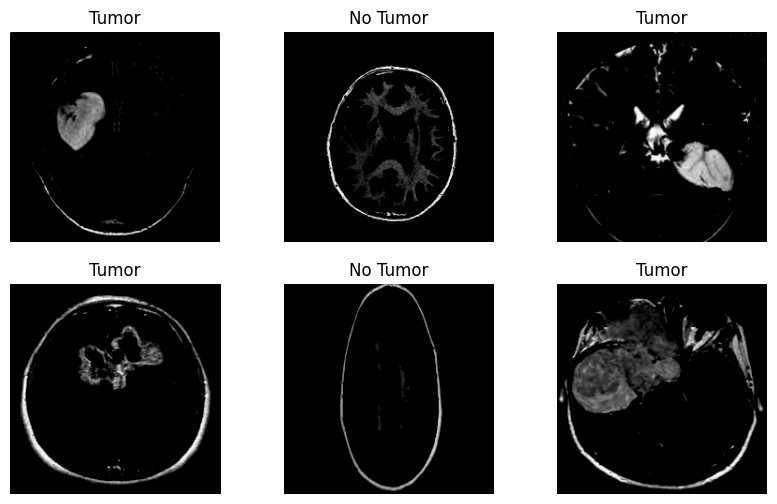

In [22]:
import matplotlib.pyplot as plt

images, labels = next(iter(test_loader))
images = images.to(device)

outputs = model(images)
_, preds = torch.max(outputs, 1)

images = images.cpu()

plt.figure(figsize=(10,6))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i].permute(1,2,0))
    plt.title("Tumor" if preds[i]==1 else "No Tumor")
    plt.axis("off")
plt.show()